# Lens Picture

This notebook demonstrates the simulation and optimization of an optical system using the `diffinytrace` package.  
It was run in **Google Colab** to take advantage of GPU acceleration and Google Drive integration for saving results.


In [ ]:
%pip install diffinytrace.zip

Processing ./diffinytrace.zip
  Preparing metadata (setup.py) ... done
  Created wheel for diffinytrace: filename=diffinytrace-2.1-py3-none-any.whl size=88812 sha256=273b42149bffa443381b815ad2938b2c9c6f2aa61afbdfb1865de6d543d04690
  Stored in directory: /tmp/pip-ephem-wheel-cache-5rea8c8a/wheels/db/ea/21/35eb070bb05c3b3e3b9b47ff193267b4ac5b0871240da78a7c
Successfully built diffinytrace
  Attempting uninstall: diffinytrace
    Found existing installation: diffinytrace 2.1
    Uninstalling diffinytrace-2.1:
      Successfully uninstalled diffinytrace-2.1


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
from os import listdir
from os.path import isfile, join
path = "gdrive/MyDrive/results_final"


Mounted at /content/gdrive


num of conv points should probably be at least  251.99999999999997


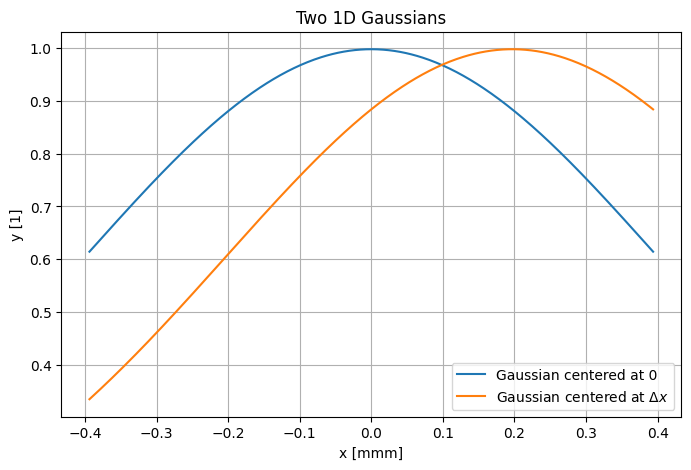

In [ ]:
import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)
import random

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


from sunlight_picture import create_lens
import os
import pickle
import gc

def save_data(data, filename):
    with open(filename, 'wb') as file:
        pickle.dump(data, file)
    print(f"Data saved to {filename}")

def load_data(filename):
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {filename}")
    return data

def create_folder(folder_path):
    try:
        os.makedirs(folder_path, exist_ok=True)
        return f"Folder created successfully at: {folder_path}" if not os.path.exists(folder_path) else f"Folder already exists at: {folder_path}"
    except Exception as e:
        return f"An error occurred: {e}"

device = "cuda:0"
image_file_name = "img1.jpg"
results_folder_main = path+"/lens_picture/"
create_folder(results_folder_main)
sigma_final = 0.4
#theta_max_rad=5.

sigmas = None
ns_start = [4,4]
orders = [3,3]
num_refinements = 6
#num_refinements = 4
lens_thickness:float=5.

theta_max_rad = 30/1000.
detector_distance:float=70.

lens_distance:float=5.0

aperture_radius_source = 21.
image_padding = 0.2
grid_size = 256
num_rays = 2**21
#[1601,1601]
from diffinytrace import utils
#from diffinytrace.nonimaging import smoothing
aperture_radius_detector = aperture_radius_source*(1+image_padding)

print("num of conv points should probably be at least ", 2.0*aperture_radius_detector*2.0/sigma_final)

import numpy as np
import matplotlib.pyplot as plt

# Parameters
dx = (aperture_radius_detector*2.0)/grid_size
x = np.linspace(-dx*2, dx*2, 500)  # x-axis range

# Gaussian 1 centered at 0
gaussian1 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma_final**2))

# Gaussian 2 centered at dx
gaussian2 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-(x - dx)**2 / (2 * sigma_final**2))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, gaussian1, label='Gaussian centered at 0')
plt.plot(x, gaussian2, label=r'Gaussian centered at $\Delta x$')
plt.title("Two 1D Gaussians")
plt.xlabel("x [mmm]")
plt.ylabel("y [1]")
plt.legend()
plt.grid()
plt.show()

gc.collect()
irr_func = utils.irradiance_importer.create_irradiance_from_image_square(image_file_name,image_padding,0.,aperture_radius_detector)

#quantity2D.plot(final_smoother.desired_smooth_irradiance.cpu().detach().numpy(),"Smoothed Desired Irr.",aperture_radius_detector,cmap="gray")
#plt.imshow(final_smoother.desired_smooth_irradiance.cpu().detach().numpy()[::-1])
#%%
def make_run(subfolder_main,use_desired_irradiance_smoothing,T_margin):
    create_folder(subfolder_main)
    subfolder = subfolder_main

    #create_folder(subfolder)
    kwargs = dict(image_file_name=image_file_name,
                lens_material=dit.materials["PMMA"],
                air_material=dit.materials["AIR"],
                device=device,
                sigma=sigma_final,
                use_desired_irradiance_smoothing=use_desired_irradiance_smoothing,
                num_rays=num_rays,
                num_refinements=num_refinements,
                grid_size=grid_size,
                theta_max_rad=theta_max_rad,
                T_margin=T_margin,
                lens_thickness=lens_thickness,
                detector_distance=detector_distance,
                lens_distance=lens_distance,
                )

    results = create_lens(**kwargs)
    save_data(results, subfolder+"/results_dict.pkl")
    del results
    gc.collect()



Only sobol_pow2,sobol or monte_carlo sampling supported for VisibleSunlightSimpleMonochromatic


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


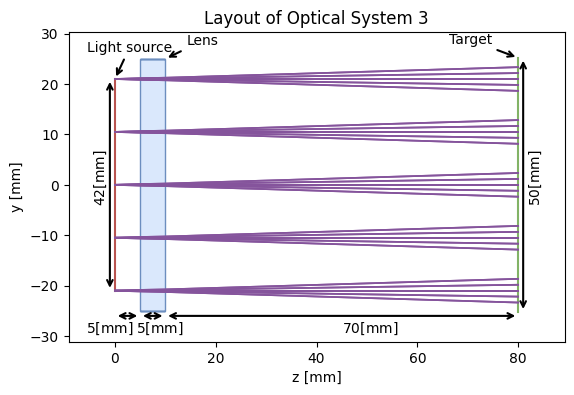

In [ ]:
from diffinytrace import (
    source, transforms, Bspline, Plane, Lens, Detector, SequentialOpticalSystem,
    utils, plotting, target_grid, render, minimize, set_unused_bspline_coeff_to_nearest,
    export, gaussian_smoother
)
import matplotlib.pyplot as plt
import diffinytrace as dit
import torch
from typing import List



aperture_radius_source:float=21.
aperture_radius_lens:float=25.
image_padding:float=0.2


lens_material=dit.materials["PMMA"]
air_material=dit.materials["AIR"]
light_transform = transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_transform.pos.requires_grad = False

light_source = None

light_source = source.VisibleSunlightSimpleMonochromatic(light_transform,aperture_radius_source,wl=0.5,total_power=1.0,theta_max_rad=theta_max_rad)
lens_transform = transforms.Distance(lens_distance,parent_transform=light_transform)

aperture_radius_detector = aperture_radius_source*(1+image_padding)

bspline_surface1 = Bspline(aperture_radius_lens,orders,ns_start)

surface1 = Plane()
lens1 = Lens(lens_transform,lens_thickness,surface1,bspline_surface1,lens_material,aperture_radius_lens,is_square=True)
lens_transform.distance.requires_grad = False
lens1.lens_thickness.requires_grad = False
detector_transform = transforms.Distance(detector_distance,parent_transform=lens1)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = Plane()
detector = Detector(detector_transform,plane_surface,aperture_radius_detector)
system = SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector},air_material)
sequence = ["source","lens","detector"]


x,weights = light_source.sample([1,5,5,5],"simpson")

#x,weights = light_source.sample(2000)

O,D,wave_len,_,RayPaths = system(x,sequence)

system.to("cpu")
offset_arrows = -(aperture_radius_lens+1)

plt.title("Layout of Optical System 3")
dit.plotting.system2D.plot(system,RayPaths,500,show = False)
dit.plotting.system2D.annotated_arrow([0,offset_arrows],[lens_distance,offset_arrows],(-30,-12),f"${int(lens_distance)}$[mm]","<->")
dit.plotting.system2D.annotated_arrow([lens_distance,offset_arrows],[lens_distance+lens_thickness,offset_arrows],(-12,-12),f"${int(lens_thickness)}$[mm]","<->")
dit.plotting.system2D.annotated_arrow([lens_distance+lens_thickness,offset_arrows],[lens_distance+lens_thickness+detector_distance,offset_arrows],(0,-12),f"${int(detector_distance)}$[mm]","<->")

dit.plotting.system2D.annotated_arrow([-1,-aperture_radius_source],[-1,aperture_radius_source],(-12,-12),f"${int(aperture_radius_source*2)}$[mm]","<->",rotation=90)
dit.plotting.system2D.annotated_arrow([lens_distance+lens_thickness+detector_distance+1,-aperture_radius_detector],[lens_distance+lens_thickness+detector_distance+1,aperture_radius_detector],(3,-12),f"${int(aperture_radius_detector*2)}$[mm]","<->",rotation=90)

dit.plotting.system2D.annotate_position([0,aperture_radius_source],(-20,20),"Light source")
dit.plotting.system2D.annotate_position([lens_distance+lens_thickness,aperture_radius_lens],(15,10),"Lens")
dit.plotting.system2D.annotate_position([lens_distance+lens_thickness+detector_distance,aperture_radius_detector],(-50,10),"Target")
plt.savefig(path+"/layout3.png", dpi=400, bbox_inches='tight')

In [ ]:

def run_all_methods():


    gc.collect()
    subfolder_main = results_folder_main+"/results_classical"
    make_run(subfolder_main,use_desired_irradiance_smoothing = False,T_margin=None)

    gc.collect()
    subfolder_main = results_folder_main+"/results_margin"
    make_run(subfolder_main,use_desired_irradiance_smoothing = True,T_margin=4*sigma_final)

    gc.collect()

    subfolder_main = results_folder_main+"/results_desired_irr_smoothing"
    make_run(subfolder_main,use_desired_irradiance_smoothing = True,T_margin=None)

    gc.collect()


run_all_methods()

in create lens
after system init
after system to device
pre smoother init
after smoother init
after eval_func init
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0085, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00849792004887
last_error (tensor(0.0085), tensor(0.0002), tensor(0.7368)) 0.008474511451000885
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0080, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00802076452311
last_error (tensor(0.0080), tensor(0.0002), tensor(0.7479)) 0.00798988653282202
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0065, device='cuda:0', grad_fn=<SqrtBackward0>) 0.0065151632737
last_error (tensor(0.0067), tensor(0.0001), tensor(0.7641)) 0.006700388297759871
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0056, device='cuda:0', grad_fn=<SqrtBackward0>) 0.005593432137
last_error (tensor(0.0059), tensor(0.0001), tensor(0.7782)

100%|██████████| 1000/1000 [12:15<00:00,  1.36it/s]


Data saved to gdrive/MyDrive/results_final/lens_picture//results_classical/results_dict.pkl
in create lens
after system init
after system to device
pre smoother init
after smoother init
after eval_func init
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0068, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00684808046407
last_error (tensor(0.0085), tensor(0.0002), tensor(0.7352)) 0.008480009312990915
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0063, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00629984123515
last_error (tensor(0.0080), tensor(0.0002), tensor(0.7474)) 0.008000840745615146
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0044, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00441184168418
last_error (tensor(0.0067), tensor(0.0001), tensor(0.7645)) 0.006659962118714969
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0030, device='cuda:0', grad

100%|██████████| 1000/1000 [12:14<00:00,  1.36it/s]


Data saved to gdrive/MyDrive/results_final/lens_picture//results_margin/results_dict.pkl
in create lens
after system init
after system to device
pre smoother init
after smoother init
after eval_func init
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0068, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00684841635347
last_error (tensor(0.0085), tensor(0.0002), tensor(0.7349)) 0.008472532662041558
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0063, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00628414920312
last_error (tensor(0.0080), tensor(0.0002), tensor(0.7468)) 0.007974617100014266
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0044, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00437496943201
last_error (tensor(0.0066), tensor(0.0001), tensor(0.7655)) 0.006639989826098506
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0030, device='cuda:0', grad_fn

100%|██████████| 1000/1000 [12:15<00:00,  1.36it/s]


Data saved to gdrive/MyDrive/results_final/lens_picture//results_desired_irr_smoothing/results_dict.pkl


In [ ]:
#import os
#os.kill(os.getpid(), 9)

Only sobol_pow2,sobol or monte_carlo sampling supported for VisibleSunlightSimpleMonochromatic


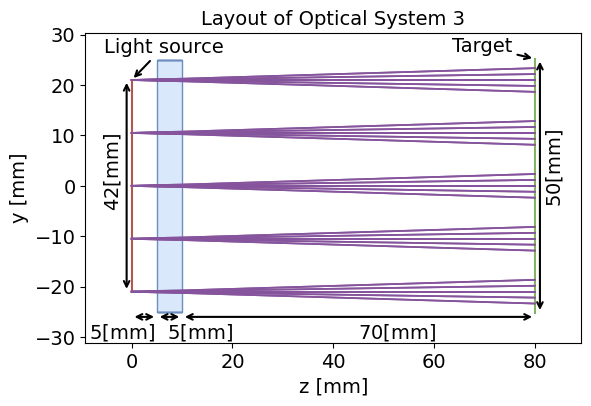

In [ ]:
from diffinytrace import (
    source, transforms, Bspline, Plane, Lens, Detector, SequentialOpticalSystem,
    utils, plotting, target_grid, render, minimize, set_unused_bspline_coeff_to_nearest,
    export, gaussian_smoother
)
import matplotlib.pyplot as plt
import diffinytrace as dit
import torch
from typing import List



aperture_radius_source:float=21.
aperture_radius_lens:float=25.
image_padding:float=0.2


lens_material=dit.materials["PMMA"]
air_material=dit.materials["AIR"]
light_transform = transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_transform.pos.requires_grad = False

light_source = None

light_source = source.VisibleSunlightSimpleMonochromatic(light_transform,aperture_radius_source,wl=0.5,total_power=1.0,theta_max_rad=theta_max_rad)
lens_transform = transforms.Distance(lens_distance,parent_transform=light_transform)

aperture_radius_detector = aperture_radius_source*(1+image_padding)

bspline_surface1 = Bspline(aperture_radius_lens,orders,ns_start)

surface1 = Plane()
lens1 = Lens(lens_transform,lens_thickness,surface1,bspline_surface1,lens_material,aperture_radius_lens,is_square=True)
lens_transform.distance.requires_grad = False
lens1.lens_thickness.requires_grad = False
detector_transform = transforms.Distance(detector_distance,parent_transform=lens1)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = Plane()
detector = Detector(detector_transform,plane_surface,aperture_radius_detector)
system = SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector},air_material)
sequence = ["source","lens","detector"]


x,weights = light_source.sample([1,5,5,5],"simpson")

#x,weights = light_source.sample(2000)

O,D,wave_len,_,RayPaths = system(x,sequence)

system.to("cpu")
offset_arrows = -(aperture_radius_lens+1)
fontsize = 14

plt.title("Layout of Optical System 3", fontsize=fontsize)
plt.xlabel("z [mm]", fontsize=fontsize)
plt.ylabel("y [mm]", fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=fontsize)
dit.plotting.system2D.plot(system,RayPaths,500,show = False)
dit.plotting.system2D.annotated_arrow([0,offset_arrows],[lens_distance,offset_arrows],(-40,-15),f"${int(lens_distance)}$[mm]","<->",fontsize=fontsize)
dit.plotting.system2D.annotated_arrow([lens_distance,offset_arrows],[lens_distance+lens_thickness,offset_arrows],(-2,-15),f"${int(lens_thickness)}$[mm]","<->",fontsize=fontsize)
dit.plotting.system2D.annotated_arrow([lens_distance+lens_thickness,offset_arrows],[lens_distance+lens_thickness+detector_distance,offset_arrows],(0,-15),f"${int(detector_distance)}$[mm]","<->",fontsize=fontsize)

dit.plotting.system2D.annotated_arrow([-1,-aperture_radius_source],[-1,aperture_radius_source],(-18,-15),f"${int(aperture_radius_source*2)}$[mm]","<->",rotation=90,fontsize=fontsize)
dit.plotting.system2D.annotated_arrow([lens_distance+lens_thickness+detector_distance+1,-aperture_radius_detector],[lens_distance+lens_thickness+detector_distance+1,aperture_radius_detector],(3,-12),f"${int(aperture_radius_detector*2)}$[mm]","<->",rotation=90,fontsize=fontsize)

dit.plotting.system2D.annotate_position([0,aperture_radius_source],(-20,20),"Light source",fontsize=fontsize)
dit.plotting.system2D.annotate_position([lens_distance+lens_thickness+detector_distance,aperture_radius_detector],(-60,5),"Target",fontsize=fontsize)
plt.savefig(path+"/layout3.png", dpi=400, bbox_inches='tight')